### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

Parametro di forma stimato (shape): 0.954116583479107


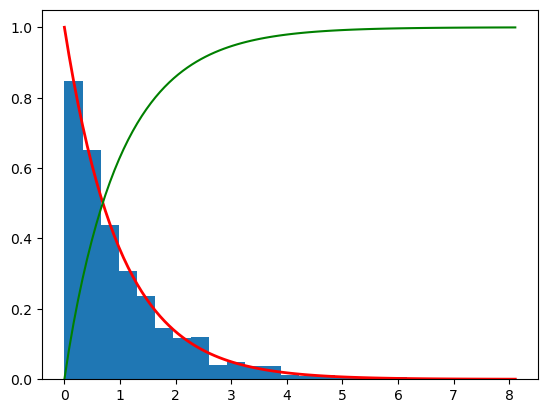

1.0283967093207065

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

#1
a = 1  
sample = gamma.rvs(a, size=1000)

plt.hist(sample, bins= 25, density=True)
x = np.linspace(0, sample.max(),100)
plt.plot(x, gamma.pdf(x, a), 'r-', lw=2, label='PDF teorica')


#2 
shape = gamma.fit(sample)
print("Parametro di forma stimato (shape):", shape[0])

#3
plt.plot(x,gamma.cdf(x,shape[0],shape[1],shape[2]), "g-")
plt.show()

#4
np.var(sample)

### **2. Fitta i dati**
Prova a fittare i dati sottostante con le migliori curve, calcola il MAE e l'RMSE

MAE: 0.78, RMSE: 0.93
MAE: 1.14, RMSE: 1.43


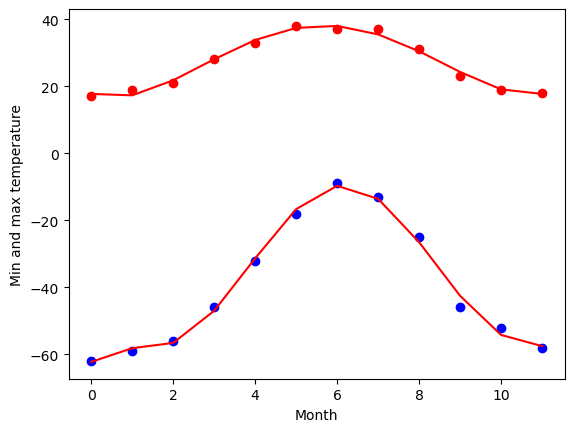

In [53]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt
months = np.arange(12)
plt.plot(months, temp_max, "ro")
plt.plot(months, temp_min, "bo")
plt.xlabel("Month")
plt.ylabel("Min and max temperature")

a = np.polyfit(months, temp_max, 4)
b = np.polyval(a,months)
plt.plot(months, b, "r-")


c = np.polyfit(months, temp_min, 6)
d = np.polyval(c,months)
plt.plot(months, d, "r-")

mae = np.mean(np.abs(temp_max - b))
rmse = np.sqrt(np.mean((temp_max - b)**2))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

mae = np.mean(np.abs(temp_min - d))
rmse = np.sqrt(np.mean((temp_min - d)**2))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

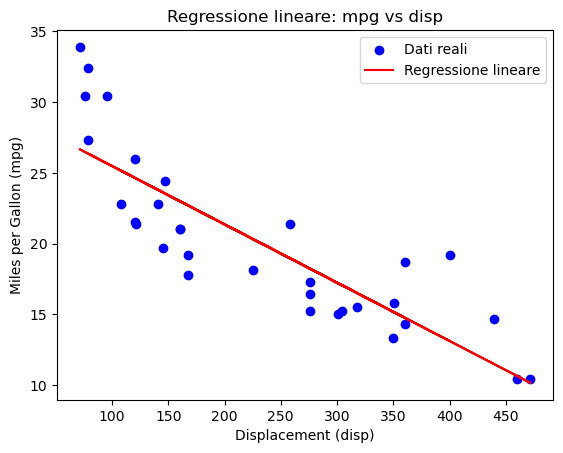

Coefficiente angolare: -0.041215119962786144
Intercetta: 29.59985475616395


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np


# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')


X = df['disp'].values.reshape(-1, 1)  
y = df['mpg'].values                  


model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


plt.scatter(df['disp'], df['mpg'], color='blue', label='Dati reali')
plt.plot(df['disp'], y_pred, color='red', label='Regressione lineare')
plt.xlabel('Displacement (disp)')
plt.ylabel('Miles per Gallon (mpg)')
plt.title('Regressione lineare: mpg vs disp')
plt.legend()
plt.show()


print(f'Coefficiente angolare: {model.coef_[0]}')
print(f'Intercetta: {model.intercept_}')